In [1]:
import numpy as np
import gnss_lib_py as glp
import pandas as pd
from gnss_lib_py.utils import constants
from dataclasses import dataclass
import matplotlib.pyplot as plt

In [ ]:
# field 1 -- FEAR IT!!!!
field1 = "raw_data/gnss_log_2025_11_18_11_29_26.txt"
# field 2 is whole sideline perimeter
field2 = "raw_data/gnss_log_2025_11_18_11_21_46.txt"
# field 3 is only fraction of sideline distance
field3 = "raw_data/gnss_log_2025_11_18_11_19_48.txt"
# oval collected 11/18 1130
oval = "raw_data/gnss_log_2025_11_18_11_49_34.txt"
# oval collected 12/02 2100
oval_night = "raw_data/gnss_log_2025_12_02_20_57_15.txt"

# initial guess is Johnson Field Google Maps coords to help converge
x_init_guess_lla_J = np.array([[37.43109060346768], [-122.15524075735037], [0]])
x_init_guess_ecef_J = glp.geodetic_to_ecef(x_init_guess_lla_J).flatten()

# initial guess for Oval Google Maps coords to help converge
x_init_guess_lla_O = np.array([[37.43087105248864], [-122.16913436591264], [0]])
x_init_guess_ecef_O = glp.geodetic_to_ecef(x_init_guess_lla_O).flatten()

# NMEA data
nmea_field1 = "raw_data/gnss_log_2025_11_18_11_29_26.nmea"
# field 2 is whole sideline perimeter
nmea_field2 = "raw_data/gnss_log_2025_11_18_11_21_46.nmea"
# field 3 is only fraction of sideline distance
nmea_field3 = "raw_data/gnss_log_2025_11_18_11_19_48.nmea"
# oval collected 11/18 1130
nmea_oval = "raw_data/gnss_log_2025_11_18_11_49_34.nmea"
# oval collected 12/02 2100
nmea_oval_night = "raw_data/gnss_log_2025_12_02_20_57_15.nmea"

# initial guess is Johnson Field Google Maps coords to help converge
x_init_guess_lla_J = np.array([[37.43109060346768], [-122.15524075735037], [0]])
x_init_guess_ecef_J = glp.geodetic_to_ecef(x_init_guess_lla_J).flatten()

nmea_field1 = glp.Nmea(nmea_field1)
nmea_field2 = glp.Nmea(nmea_field2)
nmea_oval = glp.Nmea(nmea_oval)

In [3]:
def ground_truth(exp):
  fix_data = glp.AndroidRawFixes(exp)
  fixes = []
  fix_types = np.unique(fix_data["fix_provider"]).tolist()
  for provider in fix_types:
    fix_provider = fix_data.where("fix_provider",provider)
    fix_provider.rename({"lat_rx_deg":"lat_rx_" + provider + "_deg",
                         "lon_rx_deg":"lon_rx_" + provider + "_deg",
                         "alt_rx_m":"alt_rx_" + provider + "_m",
                         }, inplace=True)
    fixes.append(fix_provider)
  fig_fix = glp.plot_map(*fixes)
  fig_fix.show()

In [4]:
def data_proc(exp):
  raw_data = glp.AndroidRawGnss(input_path=exp,
                              filter_measurements=True,
                              measurement_filters={"sv_time_uncertainty" : 500.},
                              verbose=True)
  full_states = glp.add_sv_states(raw_data, source="precise", verbose=False)
  full_states = full_states.where("gnss_id",("gps", "galileo"))

  iono_params = {
    "gps" : np.array([
        [ full_states['KlobucharAlpha0'].mean(),
          full_states['KlobucharAlpha1'].mean(),
          full_states['KlobucharAlpha2'].mean(),
          full_states['KlobucharAlpha3'].mean() ],

        [ full_states['KlobucharBeta0'].mean(),
          full_states['KlobucharBeta1'].mean(),
          full_states['KlobucharBeta2'].mean(),
          full_states['KlobucharBeta3'].mean() ]
    ])
  }

  data = full_states.pandas_df()

  # Receiver GNSS time in seconds (subtract biases)
  t_Rx_s = (data['TimeNanos'] - (data['FullBiasNanos'] + data['BiasNanos'])) * 1e-9

  # Satellite transmit time in seconds
  t_Tx_raw = data['ReceivedSvTimeNanos'] * 1e-9

  GGTO = 40e-9

  t_Tx_gps = np.where(
      data['gnss_id'].values == 'galileo',
      t_Tx_raw + GGTO,
      t_Tx_raw
  )

  # Align satellite times to same GPS week as receiver
  gps_week_s = 604800 # number of GPS seconds in a week (gnss_lib_py/utils/constants.py)
  t_Tx_aligned = t_Tx_gps + np.floor(t_Rx_s / gps_week_s) * gps_week_s

  gps_millis_corr = t_Tx_aligned *1e3

  # Compute pseudoranges in meters
  data['pr_m'] = (t_Rx_s - t_Tx_aligned) * constants.C

  data['corr_pr_m'] = data['pr_m'] + data['b_sv_m']

  pr = data['corr_pr_m'].to_numpy()
  full_states['corr_pr_m'] = pr
  state_ekf = glp.solve_gnss_ekf(full_states)

  for col_idx, nav_data_col in enumerate(state_ekf):
    initial_state_parameter = nav_data_col
    if col_idx > 1:
      break

  initial_state_parameter['b_dot_rx_guess_mps'] = 0.0
  # print(initial_state_parameter)

  tropo_delay_m, iono_delay_m = glp.calculate_pseudorange_corr(gps_millis_corr, state=initial_state_parameter, ephem=None, sv_posvel=full_states, iono_params=iono_params)

  data['corr_pr_m'] = data['pr_m'] + data['b_sv_m'] - iono_delay_m - tropo_delay_m


  # print(data.head())
  # Optional: check some results
  # print("Sample corrected pseudoranges (m):", data['pr_m'].head(10))
  # print("Median pseudorange (m):", np.median(data['pr_m']))

  return data

In [5]:
@dataclass
class Results:
  positions: np.array
  clock_biases: np.array
  timestamps: np.array
  updates: pd.DataFrame
  lla_navdata: glp.NavData


In [6]:
def get_geometry_matrix(sv_pos, x_est):
  """
  Calculates Geomtery Matrix for all satellites

  Parameters:
    sv_pos: (num_sats, 3) sat position in meters/ ECEF
    x_est: (3,) current receiver position estimate in meters / ECEF

  Returns:
    G: (num_sats, 4) Geometry Matrix w/ unit vectors pointing to all sat locations and column of 1s for clock bias term
  """
  gk = sv_pos - x_est
  norm = np.linalg.norm(gk, axis=1, keepdims=True)
  unit = gk / norm
  G = np.hstack([-unit, np.ones((sv_pos.shape[0], 1))])

  return G


def get_theoretical_pseudoranges(sv_pos, x_est, b_est):
  """
  Calculates theoretical pseudoranges given current estimate

  Parameters:
    sv_pos: (num_sats, 3) sat position in meters/ ECEF
    x_est: (3,) current receiver position estimate in meters / ECEF
    b_est: (1,) receiver clock bias estimate in meters

  Returns:
    rho_0: (num_sats, ) Theoretical pseudoranges based on sat positions and receiver position estimate in meters
  """
  delta = sv_pos - x_est
  rho_0 = np.linalg.norm(delta, axis=1) + b_est
  return rho_0


def newton_raphson_step(G, delta_rho):
  """
  Performs one newton_raphson step update

  Parameters:
    G: (num_sats, 4) Geometry Matrix w/ unit vectors pointing to all sat locations and column of 1s for clock bias term
    delta_rho: (num_sats,) Difference between theoretical and measured pseudoranges in meters

  Returns:
    del_x: (3,) Update for receiver location in meters / ECEF
    del_bu: (scalar) Update for receiver clock bias in meters
  """
  delta_rho = np.asarray(delta_rho).reshape(-1, 1)

  MPPI = np.linalg.pinv(G)
  update = MPPI @ delta_rho

  del_x = update[:3, 0]
  del_bu = update[3, 0]

  return del_x, del_bu


def newton_raphson(data_frame, x_0, b_0, max_iter, tol):
  """
  This function computes ("dummy") Newton-Raphson least squares solution over a trajectory; no Sagnac correction; no elevation or cn0 masks

  Parameters:
    data_frame: parsed full_state data from command full_states = glp.add_sv_states(raw_data, source="precise", verbose=False)
    x_0: estimated receiver position [x, y, z] in meters, shape (3,) -or- None
    b_0: estimated receiver clock bias (meters)
    max_iter = maximum iterations
    tol = acceptable tolerance for convergence (meters)

  Returns:
    positions: np.ndarray of shape (num_epochs, 3) with trajectory estimates in meters / ECEF
    clock_biases: np.ndarray of shape (num_epochs,)
    timestamps_proc: np.ndarray of timestamps corresponding to position estimates
    updates_df: DataFrame containing epoch_idx, timestamp, iteration, x_est_x, x_est_y, x_est_z, b_est,  delta_x_x, delta_x_y, delta_x_z, delta_b, residual_norm, and converged (boolean)
  """

  timestamps = np.sort(data_frame['unix_millis'].unique())
  positions = []
  clock_biases = []
  timestamps_proc = []
  updates_list = []

  for epoch_idx, t in enumerate(timestamps):
    x_est = np.array([0.0, 0.0, 0.0]) if x_0 is None else np.array(x_0, dtype = float)
    b_est = b_0

    epoch_mask = data_frame['unix_millis'] == t
    sv_pos = np.column_stack([
        data_frame['x_sv_m'][epoch_mask],
        data_frame['y_sv_m'][epoch_mask],
        data_frame['z_sv_m'][epoch_mask]
    ])
    rho_meas = data_frame['corr_pr_m'][epoch_mask]

    valid_mask = ~np.isnan(sv_pos).any(axis=1) & ~np.isnan(rho_meas)
    sv_pos = sv_pos[valid_mask]
    rho_meas = rho_meas[valid_mask]

    if len(rho_meas) < 4:
      continue

    converged_epoch = False

    for it in range (max_iter):
      G = get_geometry_matrix(sv_pos, x_est)
      rho_0 = get_theoretical_pseudoranges(sv_pos, x_est, b_est)
      delta_rho = rho_meas - rho_0

      del_x, del_bu = newton_raphson_step(G, delta_rho)
      x_est += del_x
      b_est += del_bu

      converged_it = np.all(np.abs(del_x) < tol) and abs(del_bu) < tol
      if converged_it and not converged_epoch:
        converged_epoch = True

      updates_list.append({
          "epoch_idx": epoch_idx,
          "timestamp": t,
          "iteration": it + 1,
          "x_est_x": x_est[0],
          "x_est_y": x_est[1],
          "x_est_z": x_est[2],
          "b_est": b_est,
          "delta_x_x": del_x[0],
          "delta_x_y": del_x[1],
          "delta_x_z": del_x[2],
          "delta_b": del_bu,
          "residual_norm": np.linalg.norm(delta_rho),
          "converged": converged_it
            })

      if converged_it:
        break

    positions.append(x_est.copy())
    clock_biases.append(b_est)
    timestamps_proc.append(t)

    # if converged_epoch:
    #   print(f"Epoch {t} converged after {it+1} iterations, Δx = {del_x}, Δb = {del_bu}")
    # else:
    #   print(f"Epoch {t} did NOT converge after {max_iter} iterations, last Δx = {del_x}, Δb = {del_bu}")


  positions = np.array(positions)
  clock_biases = np.array(clock_biases)
  timestamps_proc = np.array(timestamps_proc)
  updates_df = pd.DataFrame(updates_list)

  # Plot Solution
  positions_ecef = pd.DataFrame(
    positions,
    columns=["x_ecef_m", "y_ecef_m", "z_ecef_m"]
    )
  lla = glp.ecef_to_geodetic(positions_ecef)
  lla_df = pd.DataFrame(lla, columns=["lat_rx_NR_deg", "lon_rx_NR_deg", "alt_rx_NR_m"])
  lla_navdata_NR = glp.NavData(pandas_df=lla_df)

  return Results(positions, clock_biases, timestamps_proc, updates_df, lla_navdata_NR)


def get_Weight_matrix(cn0_dbhz, sv_el, sig_type, weight):
  """
  Calculates Weight Matrix for all satellites based on different weighting schemes: identity, satellite elevation, cn0, or cn0 and elevation according to Li 2022 (https://doi.org/10.3390/s22072804)

  Parameters:
    cn0_dbhz: Signal-to-Noise Ratio for each satellite in decibel-Hz
    sv_el:
    sig_type:
    weight: None / 'identity' for Newton-Raphson, 'elevation', 'cn0', or 'cn0_elev'

  Returns:
    W: (num_sats, num_sats) Weighting Matrix based on inverse of cn0^2 for each satellite
  """

  cn0_dbhz = np.asarray(cn0_dbhz)
  sig_type = np.asarray(sig_type).astype(str)
  sig_type = np.char.lower(sig_type)

  eps = 1e-12
  N = len(cn0_dbhz)

  if weight is None or weight.lower() == 'identity':
    return np.eye(N)

  sv_el_rad = np.deg2rad(sv_el)

  sin_el = np.clip(np.sin(sv_el_rad), eps, 1.0)
  sigma2_ele = (1.0 / sin_el)**2

  if weight.lower() == 'elevation':
    return np.diag(1.0 / sigma2_ele)

  if weight.lower() == 'cn0':

    cn0_lin = 10 ** (cn0_dbhz/10)
    max = np.max(cn0_lin)
    return np.diag(cn0_lin - max + eps)


  # Paper weighting scheme
  if weight.lower() == 'cn0_elev':
    a = 35.0833
    b = 0.1365
    c = -0.0005

    cn0_cal = a + b*sv_el + c*(sv_el**2)

    cn0_l1_min, cn0_l1_max = 25.0, 45.0
    cn0_l5_min, cn0_l5_max = 20.0, 40.0

    ele_scale = sigma2_ele.max() - sigma2_ele.min()

    sigma2 = np.zeros(N)

    for i in range(N):
      cn0_i = cn0_dbhz[i]
      band = sig_type[i]

      if band in ('l1', 'e1'):
        sigma2_cn0_raw = abs(cn0_i - cn0_cal[i])
        cn0_scale = cn0_l1_max - cn0_l1_min
        sigma2_cn0_norm = sigma2_cn0_raw * (ele_scale / cn0_scale)

        sigma2[i] = sigma2_cn0_norm + sigma2_ele[i]

      elif band in ('l5', 'e5a'):
        sigma2_cn0_raw = abs(cn0_i)
        cn0_scale = cn0_l5_max - cn0_l5_min
        sigma2[i] = sigma2_cn0_raw * (ele_scale / cn0_scale)

      else:
        raise ValueError(f"unknown sig_type: {band}")

    return np.diag(1.0 / (sigma2 + eps))

def WLS_step(G, W, delta_rho):
  """
  Performs one WLS step update

  Parameters:
    G: (num_sats, 4) Geometry Matrix w/ unit vectors pointing to all sat locations and column of 1s for clock bias term
    W: (num_sats, num_sate) Weighting Matrix based on inverse of cn0^2 for each satellite
    delta_rho: (num_sats,) Difference between theoretical and measured pseudoranges in meters

  Returns:
    del_x: (3,) Update for receiver location in meters / ECEF
    del_bu: (scalar) Update for receiver clock bias in meters
  """
  delta_rho = np.asarray(delta_rho).reshape(-1, 1)

  mat_math = np.linalg.pinv(G.T @ W @ G) @ G.T @ W
  update = mat_math @ delta_rho

  del_x = update[:3, 0]
  del_bu = update[3, 0]

  return del_x, del_bu


def snapshot(data_frame, x_0, b_0, max_iter, tol, el_cutoff, cn0_min, weight):
    """
    Weighted Least Squares GNSS position estimation using CN0 for weighting,
    robust against bad satellites and ill-conditioned geometry.

    Parameters:
      data_frame: parsed full_state data from command full_states = glp.add_sv_states(raw_data, source="precise", verbose=False)
      x_0: estimated receiver position [x, y, z] in meters, shape (3,) -or- None
      b_0: estimated receiver clock bias (meters)
      max_iter = maximum iterations
      tol = acceptable tolerance for convergence (meters)
      el_cuttoff: cuttoff for elevation mask (degrees)
      cn0_min = cuttoff for signal-to-noise ratio for usable satellites (dbhz)
      weight = string to determine weighting scheme; None for Newton-Raphson, any string for cn0

    Returns:
      positions: np.ndarray of shape (num_epochs, 3) with trajectory estimates in meters / ECEF
      clock_biases: np.ndarray of shape (num_epochs,)
      timestamps_proc: np.ndarray of timestamps corresponding to position estimates
      updates_df: DataFrame containing epoch_idx, timestamp, iteration, x_est_x, x_est_y, x_est_z, b_est,  delta_x_x, delta_x_y, delta_x_z, delta_b, residual_norm, and converged (boolean)
    """
    timestamps = np.sort(data_frame['unix_millis'].unique())
    positions = []
    clock_biases = []
    timestamps_proc = []
    updates_list = []

    x_prev = np.array(x_0, dtype = float)
    b_prev = b_0

    for epoch_idx, t in enumerate(timestamps):
        x_est = x_prev.copy()
        b_est = b_prev

        epoch_mask = data_frame['unix_millis'] == t

        sv_pos = np.column_stack([
            data_frame['x_sv_m'][epoch_mask],
            data_frame['y_sv_m'][epoch_mask],
            data_frame['z_sv_m'][epoch_mask]
        ])
        sv_pos_orig = sv_pos.copy()

        rho_meas = data_frame['corr_pr_m'][epoch_mask]
        cn0_dbhz = data_frame['cn0_dbhz'][epoch_mask]
        gps_millis = data_frame['gps_millis'][epoch_mask]
        gnss_ids = data_frame['gnss_id'][epoch_mask].values
        sig_type = data_frame['signal_type'][epoch_mask].values



        # Valid satellite mask
        valid_mask = ~np.isnan(sv_pos).any(axis=1) & ~np.isnan(rho_meas)
        sv_pos = sv_pos[valid_mask]
        sv_pos_orig = sv_pos_orig[valid_mask]
        rho_meas = rho_meas[valid_mask]
        cn0_dbhz = cn0_dbhz[valid_mask]
        gps_millis = gps_millis[valid_mask]
        gnss_ids = gnss_ids[valid_mask]
        sig_type = sig_type[valid_mask]

        if len(rho_meas) < 4:
            continue

        converged_epoch = False
        last_el_mask = None
        last_delta = None

        for it in range(max_iter):
            # Satellite elevation/azimuth
            rx_lat, rx_lon, rx_alt = glp.ecef_to_geodetic(np.reshape(x_est, (3, 1)))
            sv_el, sv_az = glp.ecef_to_el_az(np.reshape(x_est, (3, 1)), sv_pos.T)

            # Mask by elevation and minimum CN0
            el_mask = (sv_el > el_cutoff) & (cn0_dbhz > cn0_min)
            last_el_mask = el_mask.copy()

            if np.sum(el_mask) < 4:
                print(f"Epoch {t}: Not enough high-quality satellites, skipping")
                break

            sv_pos_masked = sv_pos[el_mask]
            sv_pos_orig_masked = sv_pos_orig[el_mask]
            rho_meas_masked = rho_meas[el_mask]
            cn0_dbhz_masked = cn0_dbhz[el_mask]
            cn0_dbhz_masked = np.array(cn0_dbhz_masked)
            
            sv_el_masked = sv_el[el_mask]
            # sv_az_masked = sv_az[el_mask]
            # gps_millis_masked = gps_millis[el_mask]
            sig_type_masked = sig_type[el_mask]
            sig_type_masked = np.array(sig_type_masked.astype(str))
            sig_type_masked = np.char.lower(sig_type_masked)

            # Sagnac Correction
            geo_dist = np.linalg.norm(sv_pos_masked - x_est.reshape(1,3), axis=1)
            tau = geo_dist / constants.C
            del_theta = constants.OMEGA_E_DOT * tau

            cosd = np.cos(del_theta)
            sind = np.sin(del_theta)

            sv_pos_corr = sv_pos_masked.copy()

            x0 = sv_pos_masked[:, 0]
            y0 = sv_pos_masked[:, 1]

            sv_pos_corr[:, 0] = cosd * x0 + sind * y0
            sv_pos_corr[:, 1] = -sind * x0 + cosd * y0


            # WLS weighting
            W = get_Weight_matrix(cn0_dbhz_masked, sv_el_masked, sig_type_masked, weight)

            # Geometry and pseudorange corrections
            G = get_geometry_matrix(sv_pos_corr, x_est)
            rho_0 = get_theoretical_pseudoranges(sv_pos_corr, x_est, b_est)
            delta_rho = rho_meas_masked - rho_0

            # Check condition number
            cond = np.linalg.cond(G.T @ W @ G)
            if cond > 1e12:
                print(f"Epoch {t}: Geometry matrix poorly conditioned (cond={cond:.2e}), skipping")
                break

            # WLS update
            del_x, del_bu = WLS_step(G, W, delta_rho)

            x_est += del_x
            b_est += del_bu

            last_delta = (del_x.copy(), del_bu)

            converged_it = np.all(np.abs(del_x) < tol) and abs(del_bu) < tol
            if converged_it and not converged_epoch:
                converged_epoch = True

            updates_list.append({
                "epoch_idx": epoch_idx,
                "timestamp": t,
                "iteration": it + 1,
                "x_est_x": x_est[0],
                "x_est_y": x_est[1],
                "x_est_z": x_est[2],
                "b_est": b_est,
                "delta_x_x": del_x[0],
                "delta_x_y": del_x[1],
                "delta_x_z": del_x[2],
                "delta_b": del_bu,
                "residual_norm": np.linalg.norm(delta_rho),
                "converged": converged_it
            })


            if converged_it:
              break

        if last_el_mask is not None and np.sum(el_mask) >= 4:
          if converged_epoch:
            positions.append(x_est.copy())
            clock_biases.append(b_est)
            timestamps_proc.append(t)

            x_prev = x_est.copy()
            b_prev = b_est

            # if last_delta is not None:
            #   dx, db = last_delta
            #   print(f"Epoch {t} converged after {it+1} iterations, Δx = {del_x}, Δb = {del_bu}")

            # else:
            #     print(f"Epoch {t} did NOT converge after {max_iter} iterations, last Δx = {del_x}, Δb = {del_bu}")

    positions = np.array(positions)
    clock_biases = np.array(clock_biases)
    timestamps_proc = np.array(timestamps_proc)
    updates_df = pd.DataFrame(updates_list)

    positions_sagnac = positions.copy()
    for i, x_est in enumerate(positions):
      sv_pos_epoch = sv_pos_orig_masked

      geo_dist = np.linalg.norm(sv_pos_epoch - x_est.reshape(1,3), axis = 1)
      tau = geo_dist / constants.C
      del_theta = constants.OMEGA_E_DOT * tau

      avg_theta = np.mean(del_theta)

      x, y, z = x_est
      x_rot = np.cos(avg_theta)*x + np.sin(avg_theta)*y
      y_rot = -np.sin(avg_theta)*x + np.cos(avg_theta)*y
      z_rot = z

      positions_sagnac[i] = np.array([x_rot, y_rot, z_rot])


  # Plot Solution
    positions_ecef = pd.DataFrame(
    positions_sagnac,
    columns=["x_ecef_m", "y_ecef_m", "z_ecef_m"]
    )
    lla = glp.ecef_to_geodetic(positions_ecef)
    lla_df = pd.DataFrame(lla, columns=["lat_rx_WLS_deg", "lon_rx_WLS_deg", "alt_rx_WLS_m"])
    lla_navdata_WLS = glp.NavData(pandas_df=lla_df)

    return Results(positions, clock_biases, timestamps_proc, updates_df, lla_navdata_WLS)



In [7]:
def run(exp, x_init_guess_ecef, max_iterations, tolerance, el_mask_cut, cn0_cut, w_scheme):

  fix_data = glp.AndroidRawFixes(exp)
  fixes = []
  fix_types = np.unique(fix_data["fix_provider"]).tolist()

  for provider in fix_types:
    fix_provider = fix_data.where("fix_provider",provider)
    fix_provider.rename({"lat_rx_deg":"lat_rx_" + provider + "_deg",
                         "lon_rx_deg":"lon_rx_" + provider + "_deg",
                         "alt_rx_m":"alt_rx_" + provider + "_m",
                         }, inplace=True)
    fixes.append(fix_provider)

  data = data_proc(exp)

  Results_NR = newton_raphson(data_frame=data, x_0=None, b_0=0.0, max_iter=max_iterations, tol=tolerance)

  Results_WLS = snapshot(data_frame=data, x_0=x_init_guess_ecef, b_0=0., max_iter=max_iterations, tol=tolerance, el_cutoff=el_mask_cut, cn0_min=cn0_cut, weight=w_scheme)



  fig = glp.plot_map(*fixes, Results_NR.lla_navdata, Results_WLS.lla_navdata)
  fig.show()

  return Results_NR, Results_WLS

In [8]:
Results_NR_oval, Results_WLS_oval_i = run(exp=oval,
                                            x_init_guess_ecef=x_init_guess_ecef_O,
                                            max_iterations=10,
                                            tolerance=0.01,
                                            el_mask_cut=10,
                                            cn0_cut=20,
                                            w_scheme = 'identity')

sv_time_uncertainty removed 0


In [9]:
Results_NR_oval, Results_WLS_oval_cn0 = run(exp=oval,
                                            x_init_guess_ecef=x_init_guess_ecef_O,
                                            max_iterations=10,
                                            tolerance=0.01,
                                            el_mask_cut=10,
                                            cn0_cut=20,
                                            w_scheme = 'cn0')

sv_time_uncertainty removed 0


In [10]:
Results_NR_oval, Results_WLS_oval_elev = run(exp=oval,
                                            x_init_guess_ecef=x_init_guess_ecef_O,
                                            max_iterations=10,
                                            tolerance=0.01,
                                            el_mask_cut=10,
                                            cn0_cut=20,
                                            w_scheme = 'elevation')

sv_time_uncertainty removed 0


In [11]:
Results_NR_oval, Results_WLS_oval_cn0_elev = run(exp=oval,
                                            x_init_guess_ecef=x_init_guess_ecef_O,
                                            max_iterations=10,
                                            tolerance=0.01,
                                            el_mask_cut=10,
                                            cn0_cut=20,
                                            w_scheme = 'cn0_elev')

sv_time_uncertainty removed 0


In [12]:
Results_NR_field2, Results_WLS_field2_i = run(exp=field2,
                                            x_init_guess_ecef=x_init_guess_ecef_J,
                                            max_iterations=10,
                                            tolerance=0.01,
                                            el_mask_cut=10,
                                            cn0_cut=20,
                                            w_scheme = 'identity')

sv_time_uncertainty removed 0


In [13]:
Results_NR_field2, Results_WLS_field2_cn0 = run(exp=field2,
                                            x_init_guess_ecef=x_init_guess_ecef_J,
                                            max_iterations=10,
                                            tolerance=0.01,
                                            el_mask_cut=10,
                                            cn0_cut=20,
                                            w_scheme = 'cn0')

sv_time_uncertainty removed 0


In [14]:
Results_NR_field2, Results_WLS_field2_elev = run(exp=field2,
                                            x_init_guess_ecef=x_init_guess_ecef_J,
                                            max_iterations=10,
                                            tolerance=0.01,
                                            el_mask_cut=10,
                                            cn0_cut=20,
                                            w_scheme = 'elevation')

sv_time_uncertainty removed 0


In [15]:
Results_NR_field2, Results_WLS_field2_cn0_elev = run(exp=field2,
                                            x_init_guess_ecef=x_init_guess_ecef_J,
                                            max_iterations=10,
                                            tolerance=0.01,
                                            el_mask_cut=10,
                                            cn0_cut=20,
                                            w_scheme = 'cn0_elev')

sv_time_uncertainty removed 0


In [16]:
Results_NR_field1, Results_WLS_field1_i = run(exp=field1,
                                            x_init_guess_ecef=x_init_guess_ecef_J,
                                            max_iterations=10,
                                            tolerance=0.01,
                                            el_mask_cut=10,
                                            cn0_cut=20,
                                            w_scheme = 'identity')

sv_time_uncertainty removed 0


In [17]:
Results_NR_field1, Results_WLS_field1_cn0 = run(exp=field1,
                                            x_init_guess_ecef=x_init_guess_ecef_J,
                                            max_iterations=10,
                                            tolerance=0.01,
                                            el_mask_cut=10,
                                            cn0_cut=20,
                                            w_scheme = 'cn0')

sv_time_uncertainty removed 0


In [18]:
Results_NR_field1, Results_WLS_field1_elev = run(exp=field1,
                                            x_init_guess_ecef=x_init_guess_ecef_J,
                                            max_iterations=10,
                                            tolerance=0.01,
                                            el_mask_cut=10,
                                            cn0_cut=20,
                                            w_scheme = 'elevation')

sv_time_uncertainty removed 0


In [19]:
Results_NR_field1, Results_WLS_field1_cn0_elev = run(exp=field1,
                                            x_init_guess_ecef=x_init_guess_ecef_J,
                                            max_iterations=10,
                                            tolerance=0.01,
                                            el_mask_cut=10,
                                            cn0_cut=20,
                                            w_scheme = 'cn0_elev')

sv_time_uncertainty removed 0


In [20]:
def error_histogram(ground_truth, estimate):
    """Plot histogram of errors in meters."""

    R = 6378137  # Earth radius in meters

    # extract data
    gt_idxs = [i[0] for i in glp.find_wildcard_indexes(
        ground_truth, ["lat_rx*_deg", "lon_rx*_deg", 'alt_rx*_m'], max_allow=1).values()]
    est_idxs = [i[0] for i in glp.find_wildcard_indexes(
        estimate, ["lat_rx_*_deg","lon_rx_*_deg", 'alt_rx_*_m'], max_allow=1).values()]

    gt = ground_truth[gt_idxs]
    est = estimate[est_idxs]

    # Differences in degrees/meters
    dlat = (gt[0,:] - est[0,:]) * np.pi/180 * R
    dlon = (gt[1,:] - est[1,:]) * np.pi/180 * R * np.cos(np.deg2rad(gt[0,:]))
    dalt = (gt[2,:] - est[2,:])  # already in meters

    # Total error magnitude
    errors = np.sqrt(dlat**2 + dlon**2 + dalt**2)

    # ---- Plot histograms ----
    fig = plt.figure(figsize=(10,8))

    plt.subplot(221)
    plt.hist(errors, bins=50)
    plt.title("Total Error [m]")

    plt.subplot(222)
    plt.hist(dlat,bins=50)
    plt.title("North Error [m]")

    plt.subplot(223)
    plt.hist(dlon,bins=50)
    plt.title("East Error [m]")

    plt.subplot(224)
    plt.hist(dalt,bins=50)
    plt.title("Down Error [m]")

    plt.tight_layout()

    # 2D error plot
    fig2d = plt.figure(figsize=(6,5))
    plt.hist2d(dlon, dlat, bins=50, cmin=1)
    plt.xlabel("East Error [m]")
    plt.ylabel("North Error [m]")
    plt.title("2D Position Error Density")
    plt.colorbar()

    return fig, fig2d

(<Figure size 1000x800 with 4 Axes>, <Figure size 600x500 with 2 Axes>)

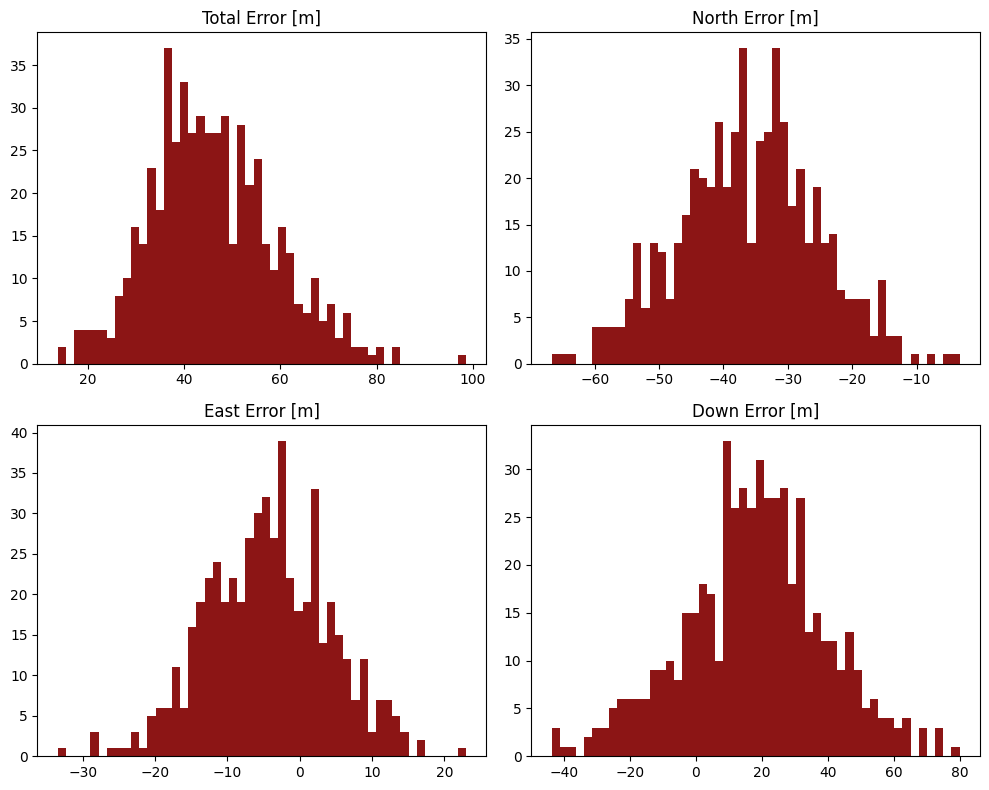

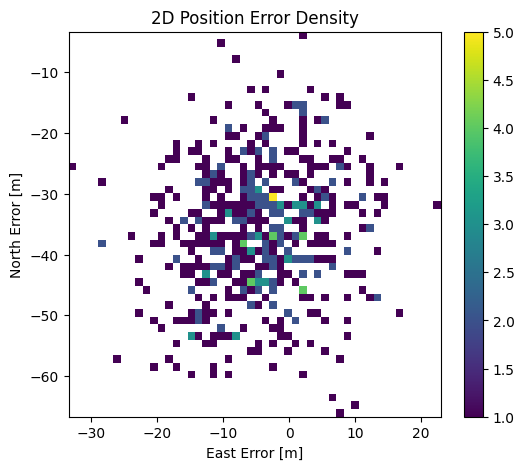

In [21]:
error_histogram(nmea_oval, Results_WLS_oval_i.lla_navdata)

(<Figure size 1000x800 with 4 Axes>, <Figure size 600x500 with 2 Axes>)

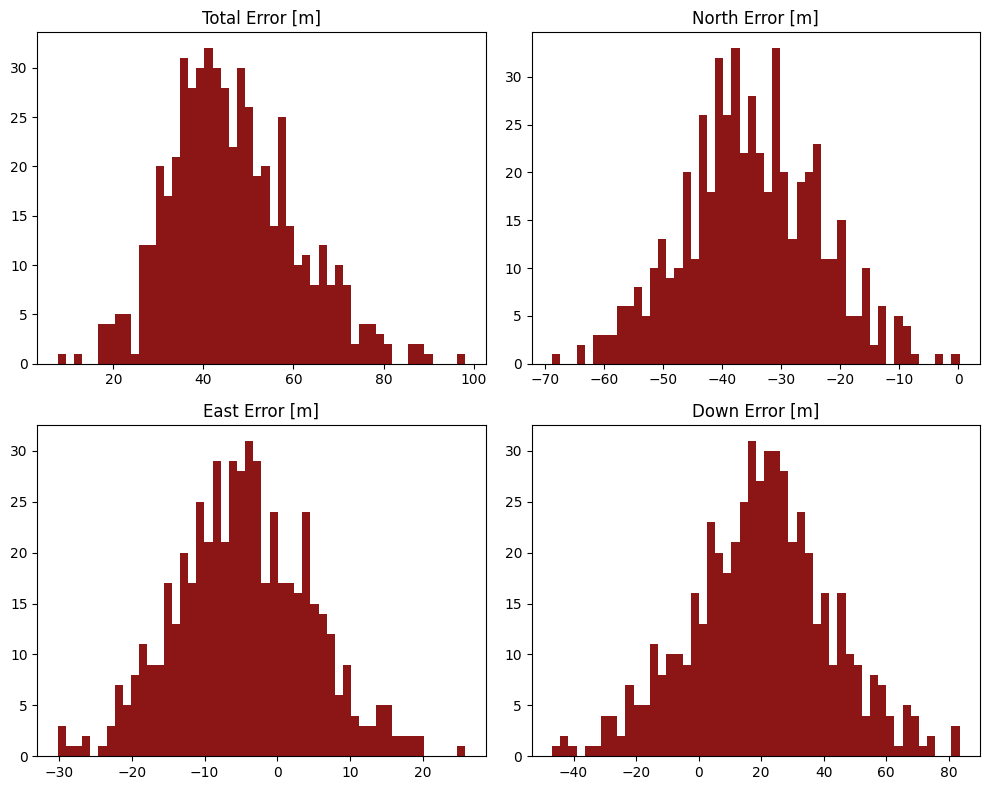

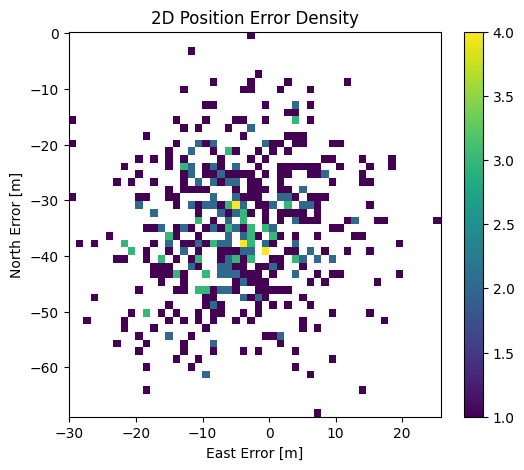

In [22]:
error_histogram(nmea_oval, Results_WLS_oval_cn0.lla_navdata)

(<Figure size 1000x800 with 4 Axes>, <Figure size 600x500 with 2 Axes>)

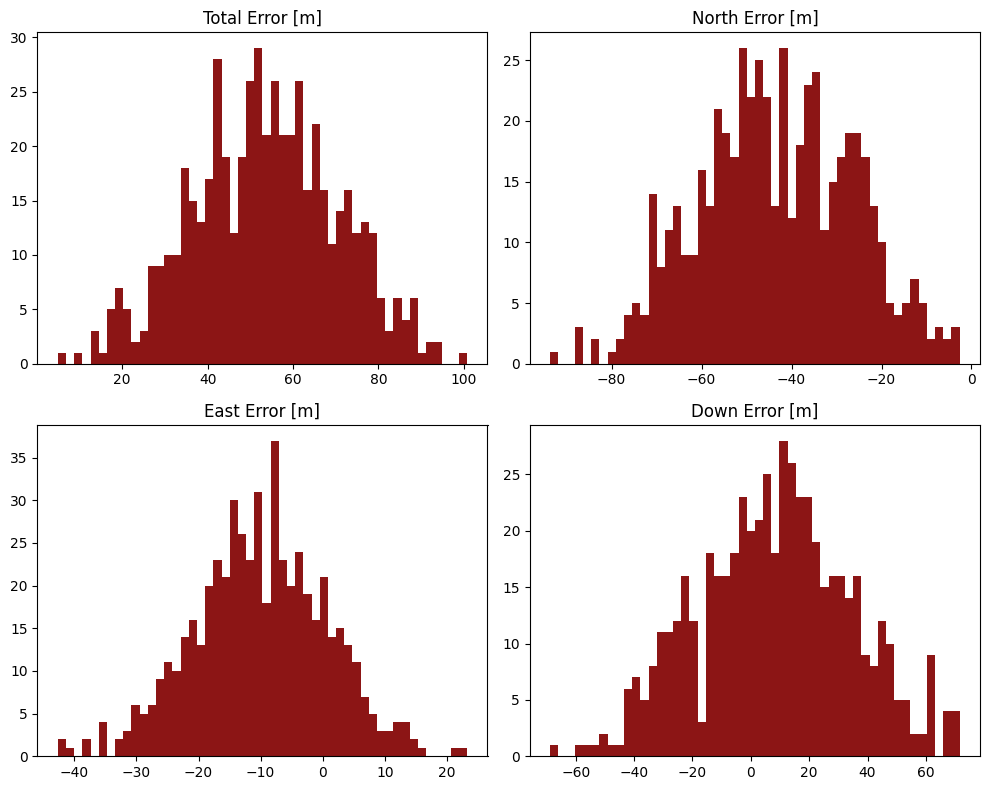

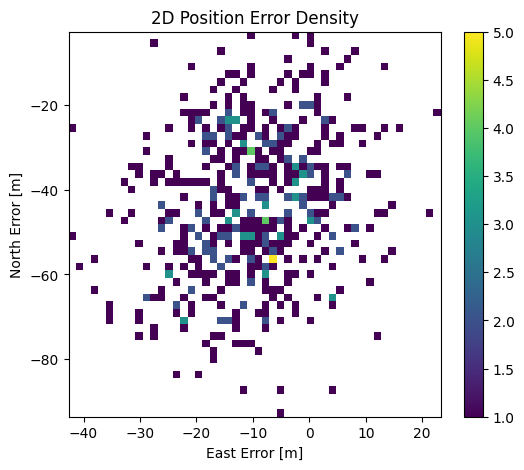

In [23]:
error_histogram(nmea_oval, Results_WLS_oval_elev.lla_navdata)

(<Figure size 1000x800 with 4 Axes>, <Figure size 600x500 with 2 Axes>)

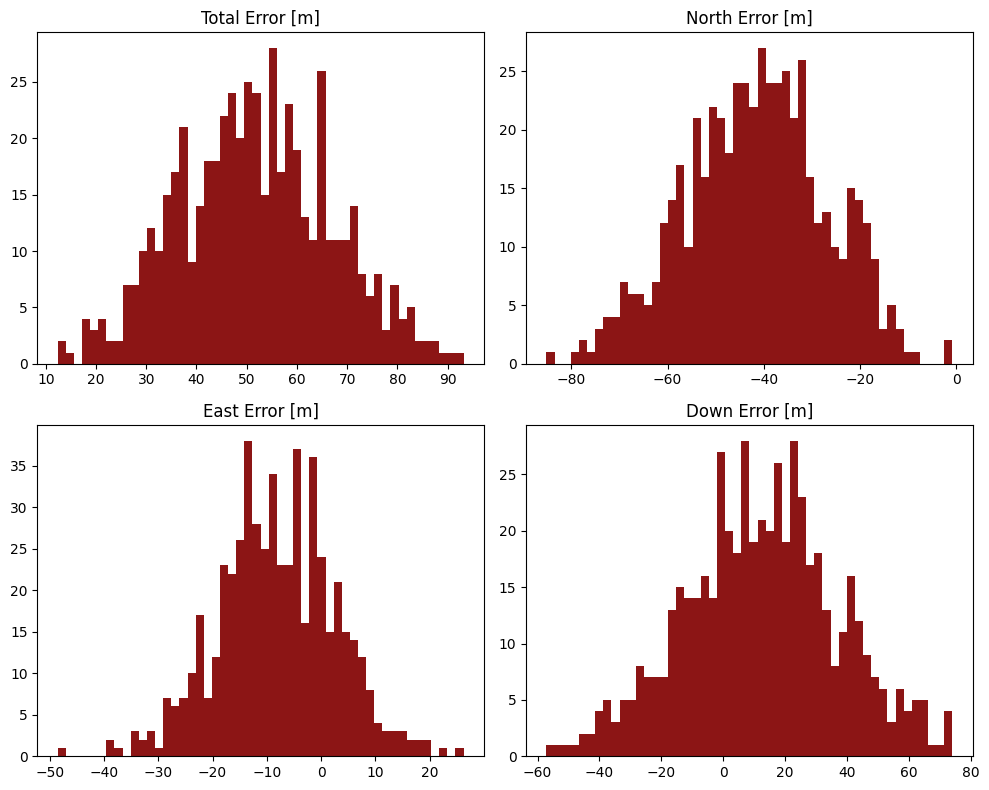

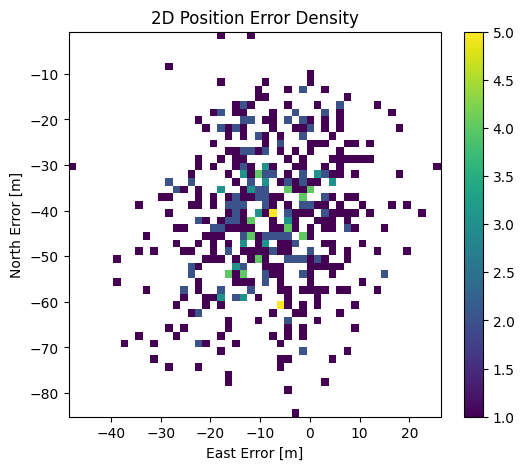

In [24]:
error_histogram(nmea_oval, Results_WLS_oval_cn0_elev.lla_navdata)

(<Figure size 1000x800 with 4 Axes>, <Figure size 600x500 with 2 Axes>)

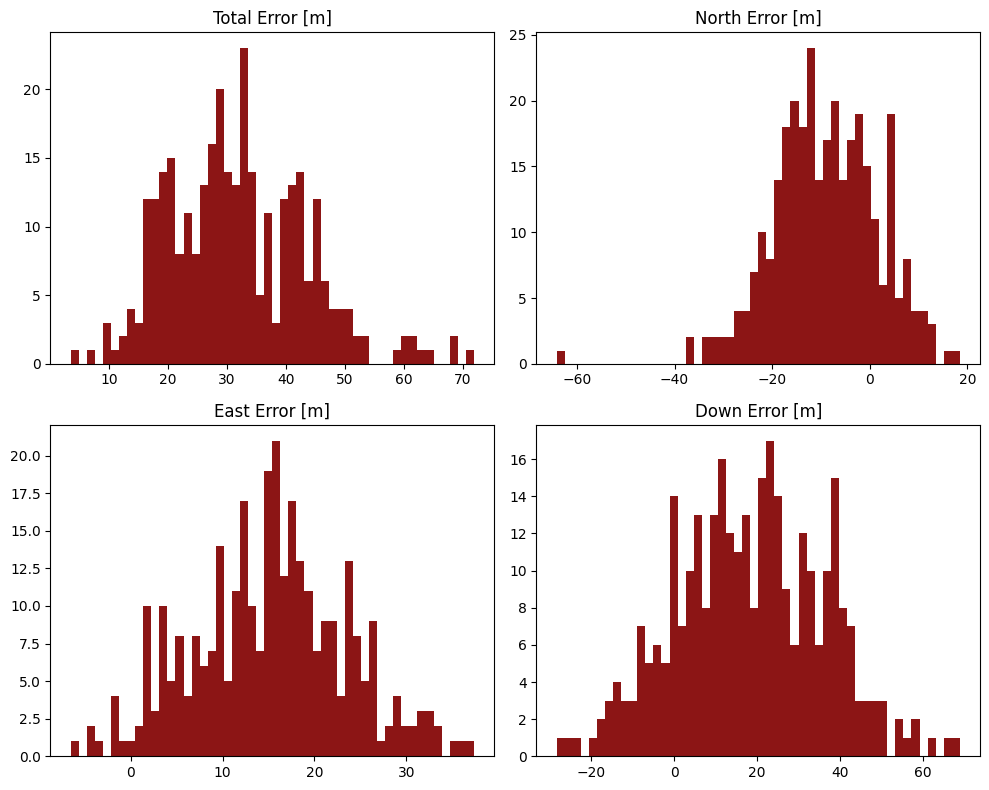

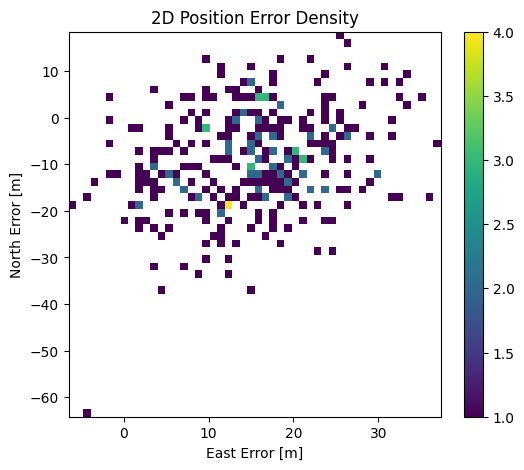

In [25]:
error_histogram(nmea_field2, Results_WLS_field2_i.lla_navdata)

(<Figure size 1000x800 with 4 Axes>, <Figure size 600x500 with 2 Axes>)

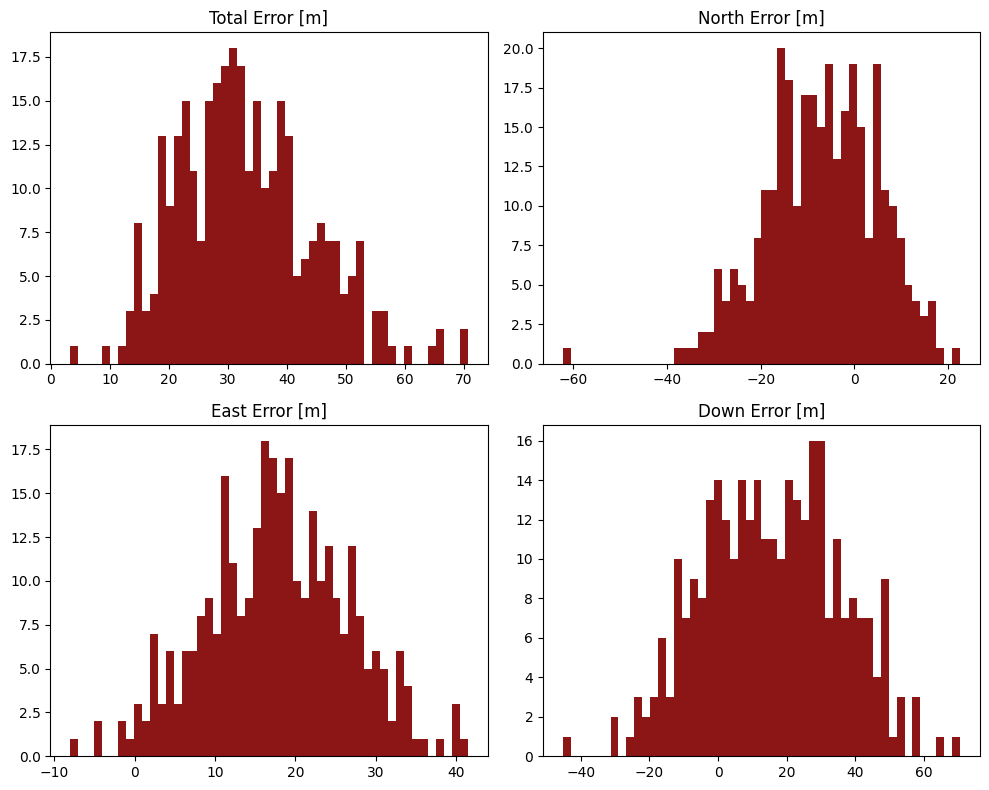

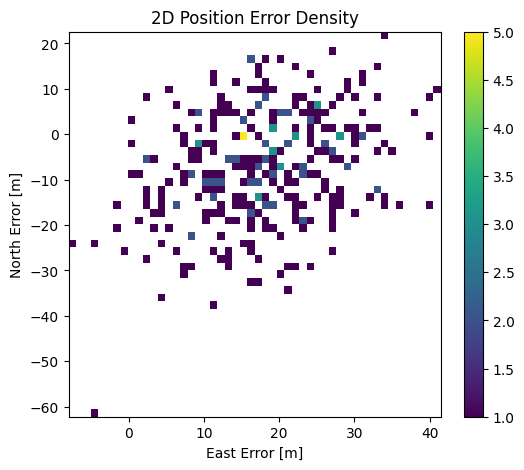

In [26]:
error_histogram(nmea_field2, Results_WLS_field2_cn0.lla_navdata)

(<Figure size 1000x800 with 4 Axes>, <Figure size 600x500 with 2 Axes>)

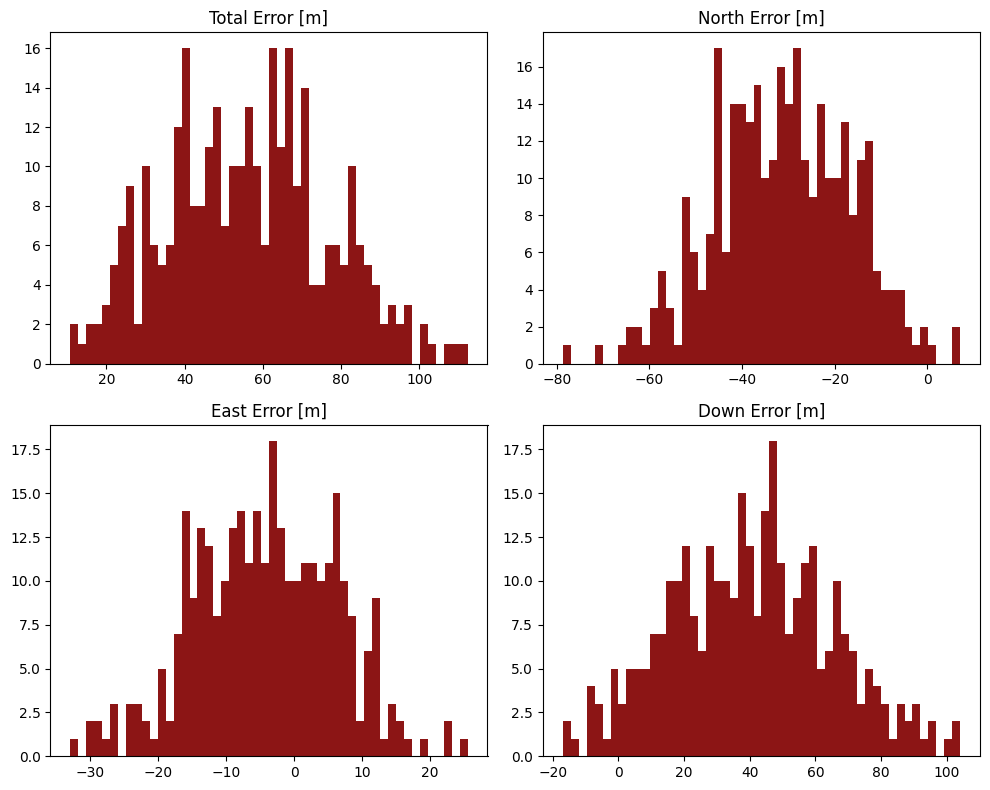

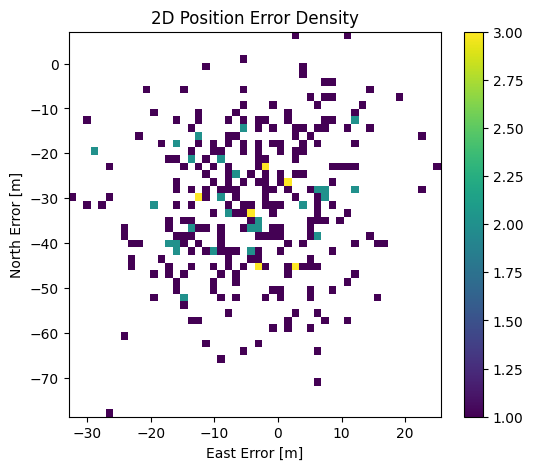

In [27]:
error_histogram(nmea_field2, Results_WLS_field2_elev.lla_navdata)

(<Figure size 1000x800 with 4 Axes>, <Figure size 600x500 with 2 Axes>)

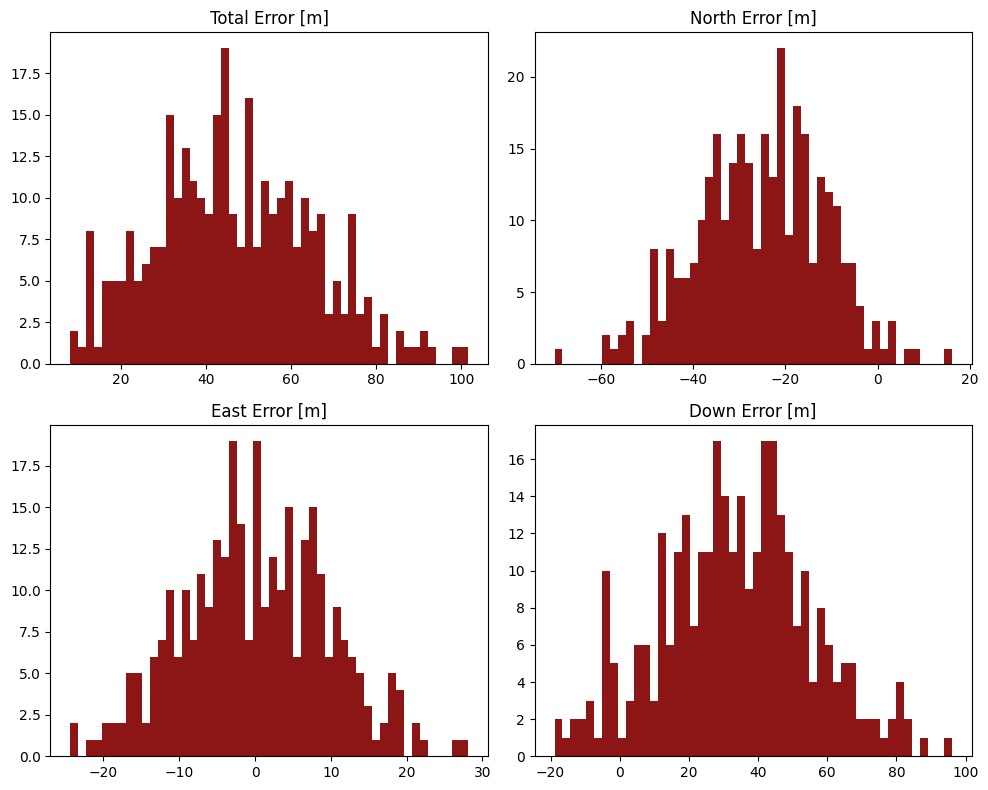

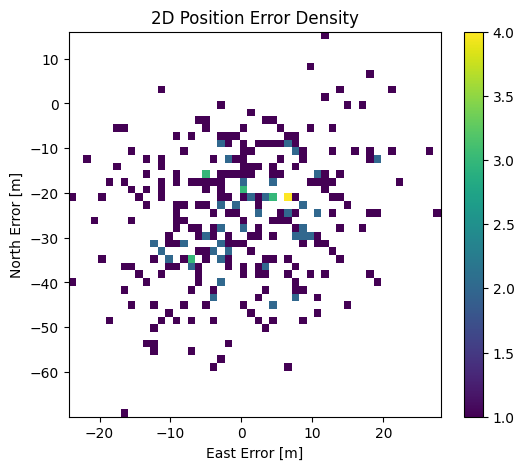

In [28]:
error_histogram(nmea_field2, Results_WLS_field2_cn0_elev.lla_navdata)

(<Figure size 1000x800 with 4 Axes>, <Figure size 600x500 with 2 Axes>)

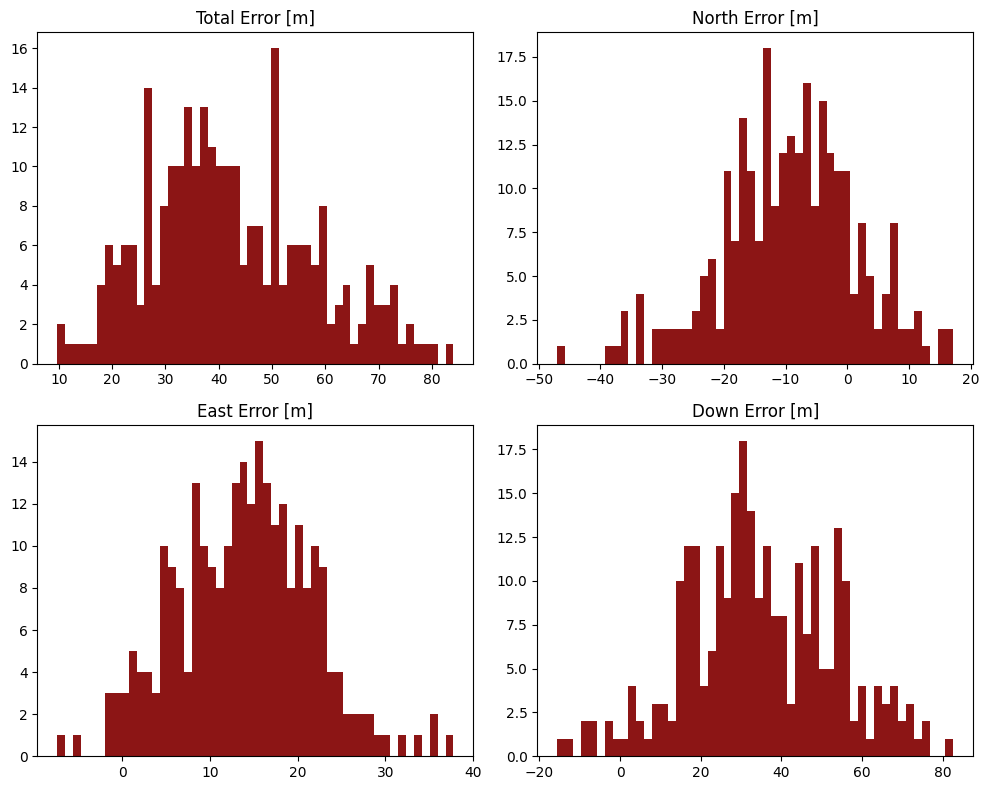

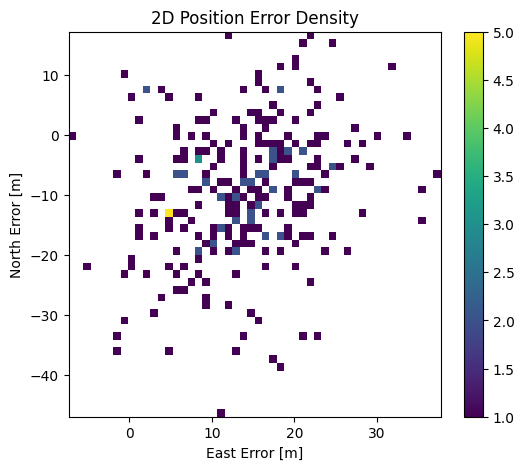

In [29]:
error_histogram(nmea_field1, Results_WLS_field1_i.lla_navdata)

(<Figure size 1000x800 with 4 Axes>, <Figure size 600x500 with 2 Axes>)

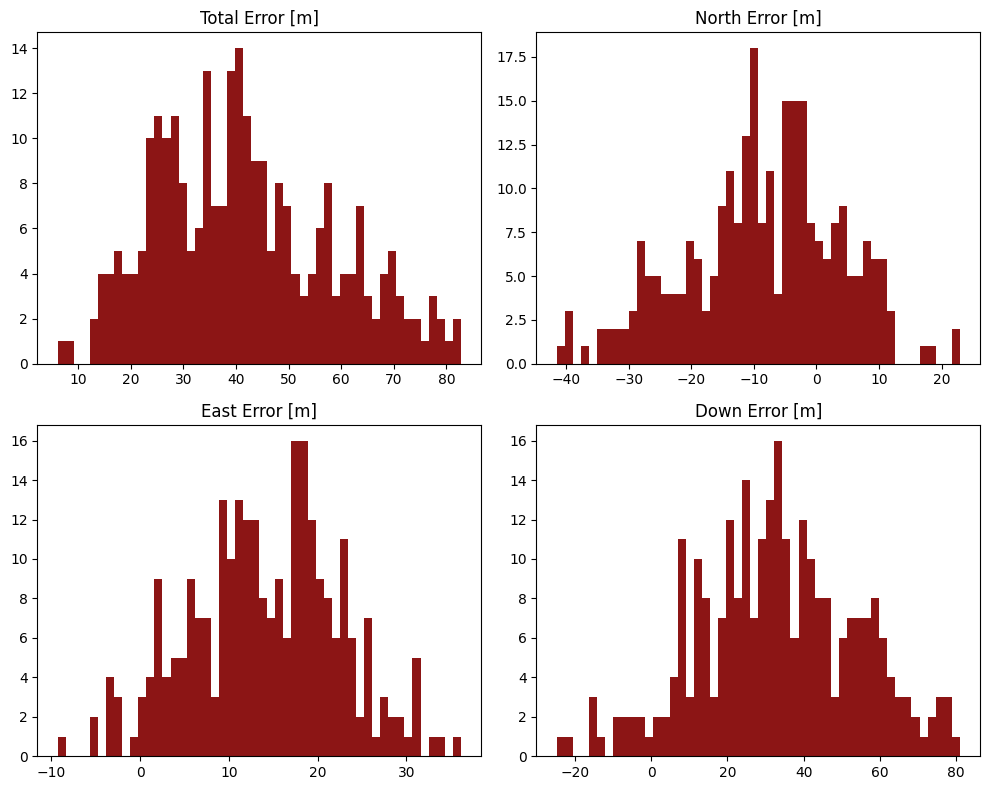

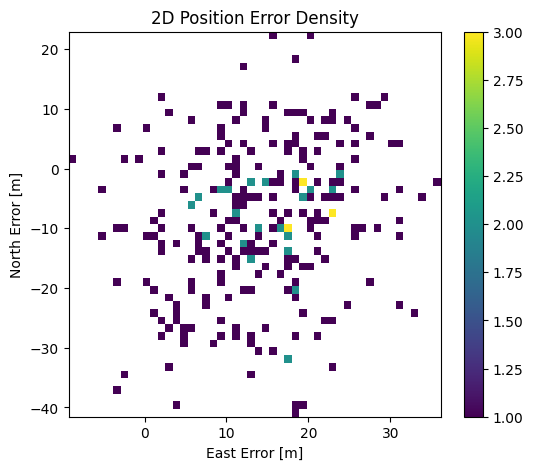

In [30]:
error_histogram(nmea_field1, Results_WLS_field1_cn0.lla_navdata)

(<Figure size 1000x800 with 4 Axes>, <Figure size 600x500 with 2 Axes>)

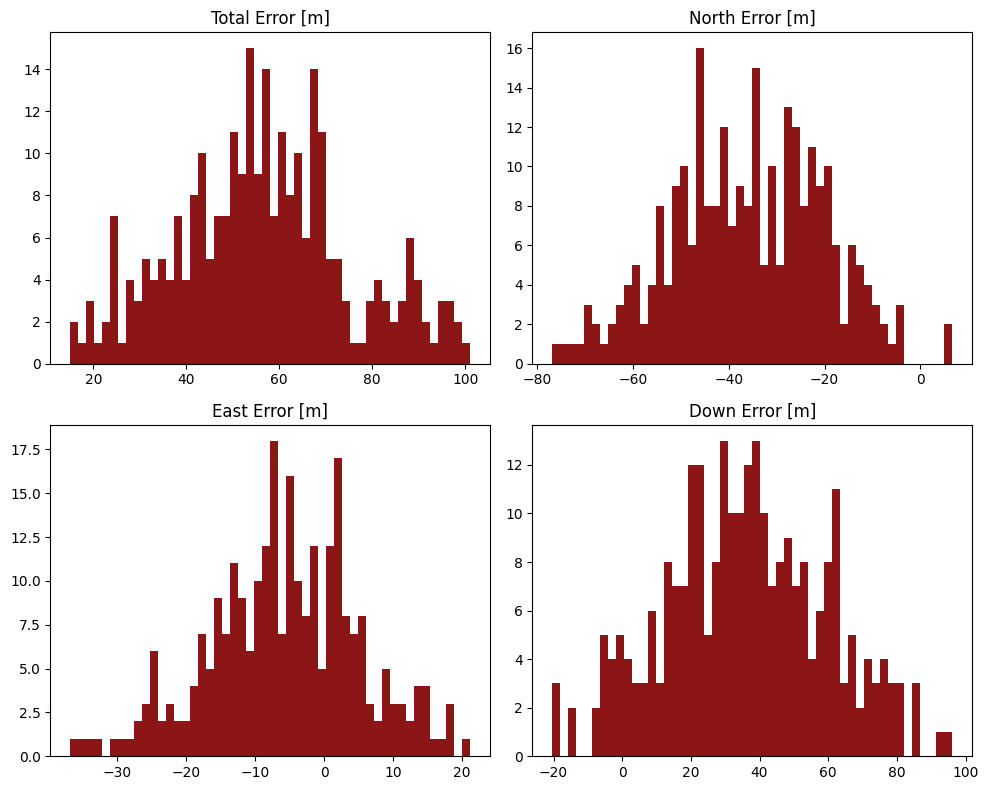

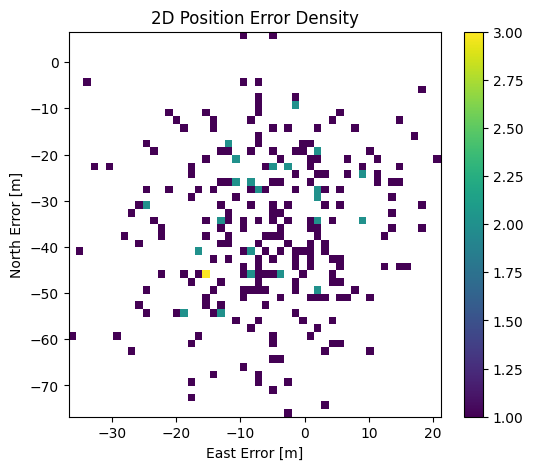

In [31]:
error_histogram(nmea_field1, Results_WLS_field1_elev.lla_navdata)

(<Figure size 1000x800 with 4 Axes>, <Figure size 600x500 with 2 Axes>)

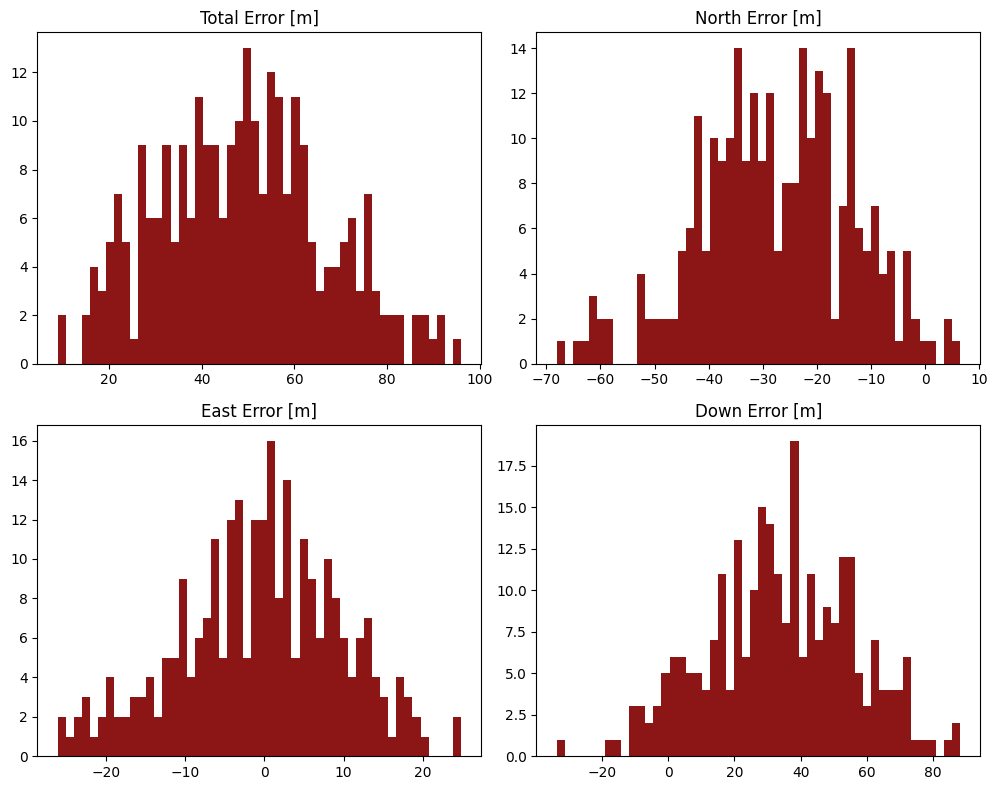

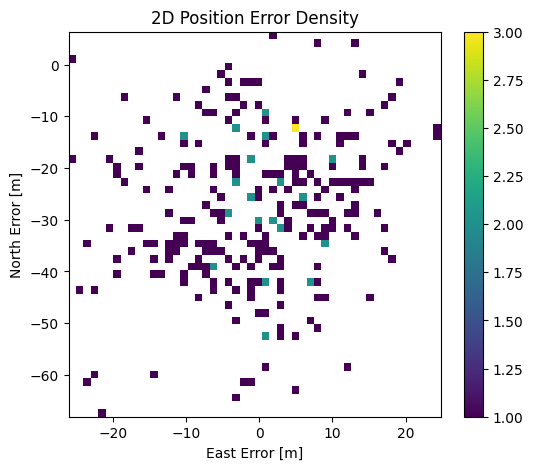

In [32]:
error_histogram(nmea_field1, Results_WLS_field1_cn0_elev.lla_navdata)